### Rainfall distribution for the entire time series / area

In [1]:
import os
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def ecdf_mask(x, thr=0.5, tie_method="average"):
    x = np.asarray(x)
    order = np.argsort(x, kind="mergesort")       
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(x) + 1)
    if tie_method == "average":
        pass
    # ECDF：F_n(x_i) = rank_i / n
    ecdf = ranks / len(x)
    return ecdf > thr

def filter_top_half(x, thr=0.5, tie_method="average"):
    mask = ecdf_mask(x, thr=thr, tie_method=tie_method)
    return x[mask]

### Plot in the Same Plot

Target Loaded
ACCESS-CM2 starts to be loaded.
ACCESS-ESM1-5 starts to be loaded.
AORC_21_31 starts to be loaded.
BCC-CSM2-MR starts to be loaded.
CESM2 starts to be loaded.
CMCC-CM2-SR5 starts to be loaded.
CNRM-ESM2-1 starts to be loaded.
CanESM5 starts to be loaded.
EC-Earth3-Veg-LR starts to be loaded.
FGOALS-g3 starts to be loaded.
GFDL-CM4_gr2 starts to be loaded.
GFDL-ESM4 starts to be loaded.
INM-CM5-0 starts to be loaded.
IPSL-CM6A-LR starts to be loaded.
KIOST-ESM starts to be loaded.
MIROC-ES2L starts to be loaded.
MIROC6 starts to be loaded.
MPI-ESM1-2-HR starts to be loaded.
MPI-ESM1-2-LR starts to be loaded.
MRI-ESM2-0 starts to be loaded.
NESM3 starts to be loaded.
NorESM2-LM starts to be loaded.
TaiESM1 starts to be loaded.


/state/partition1/job-2055160/ipykernel_3328344/3159328086.py:202: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.97])


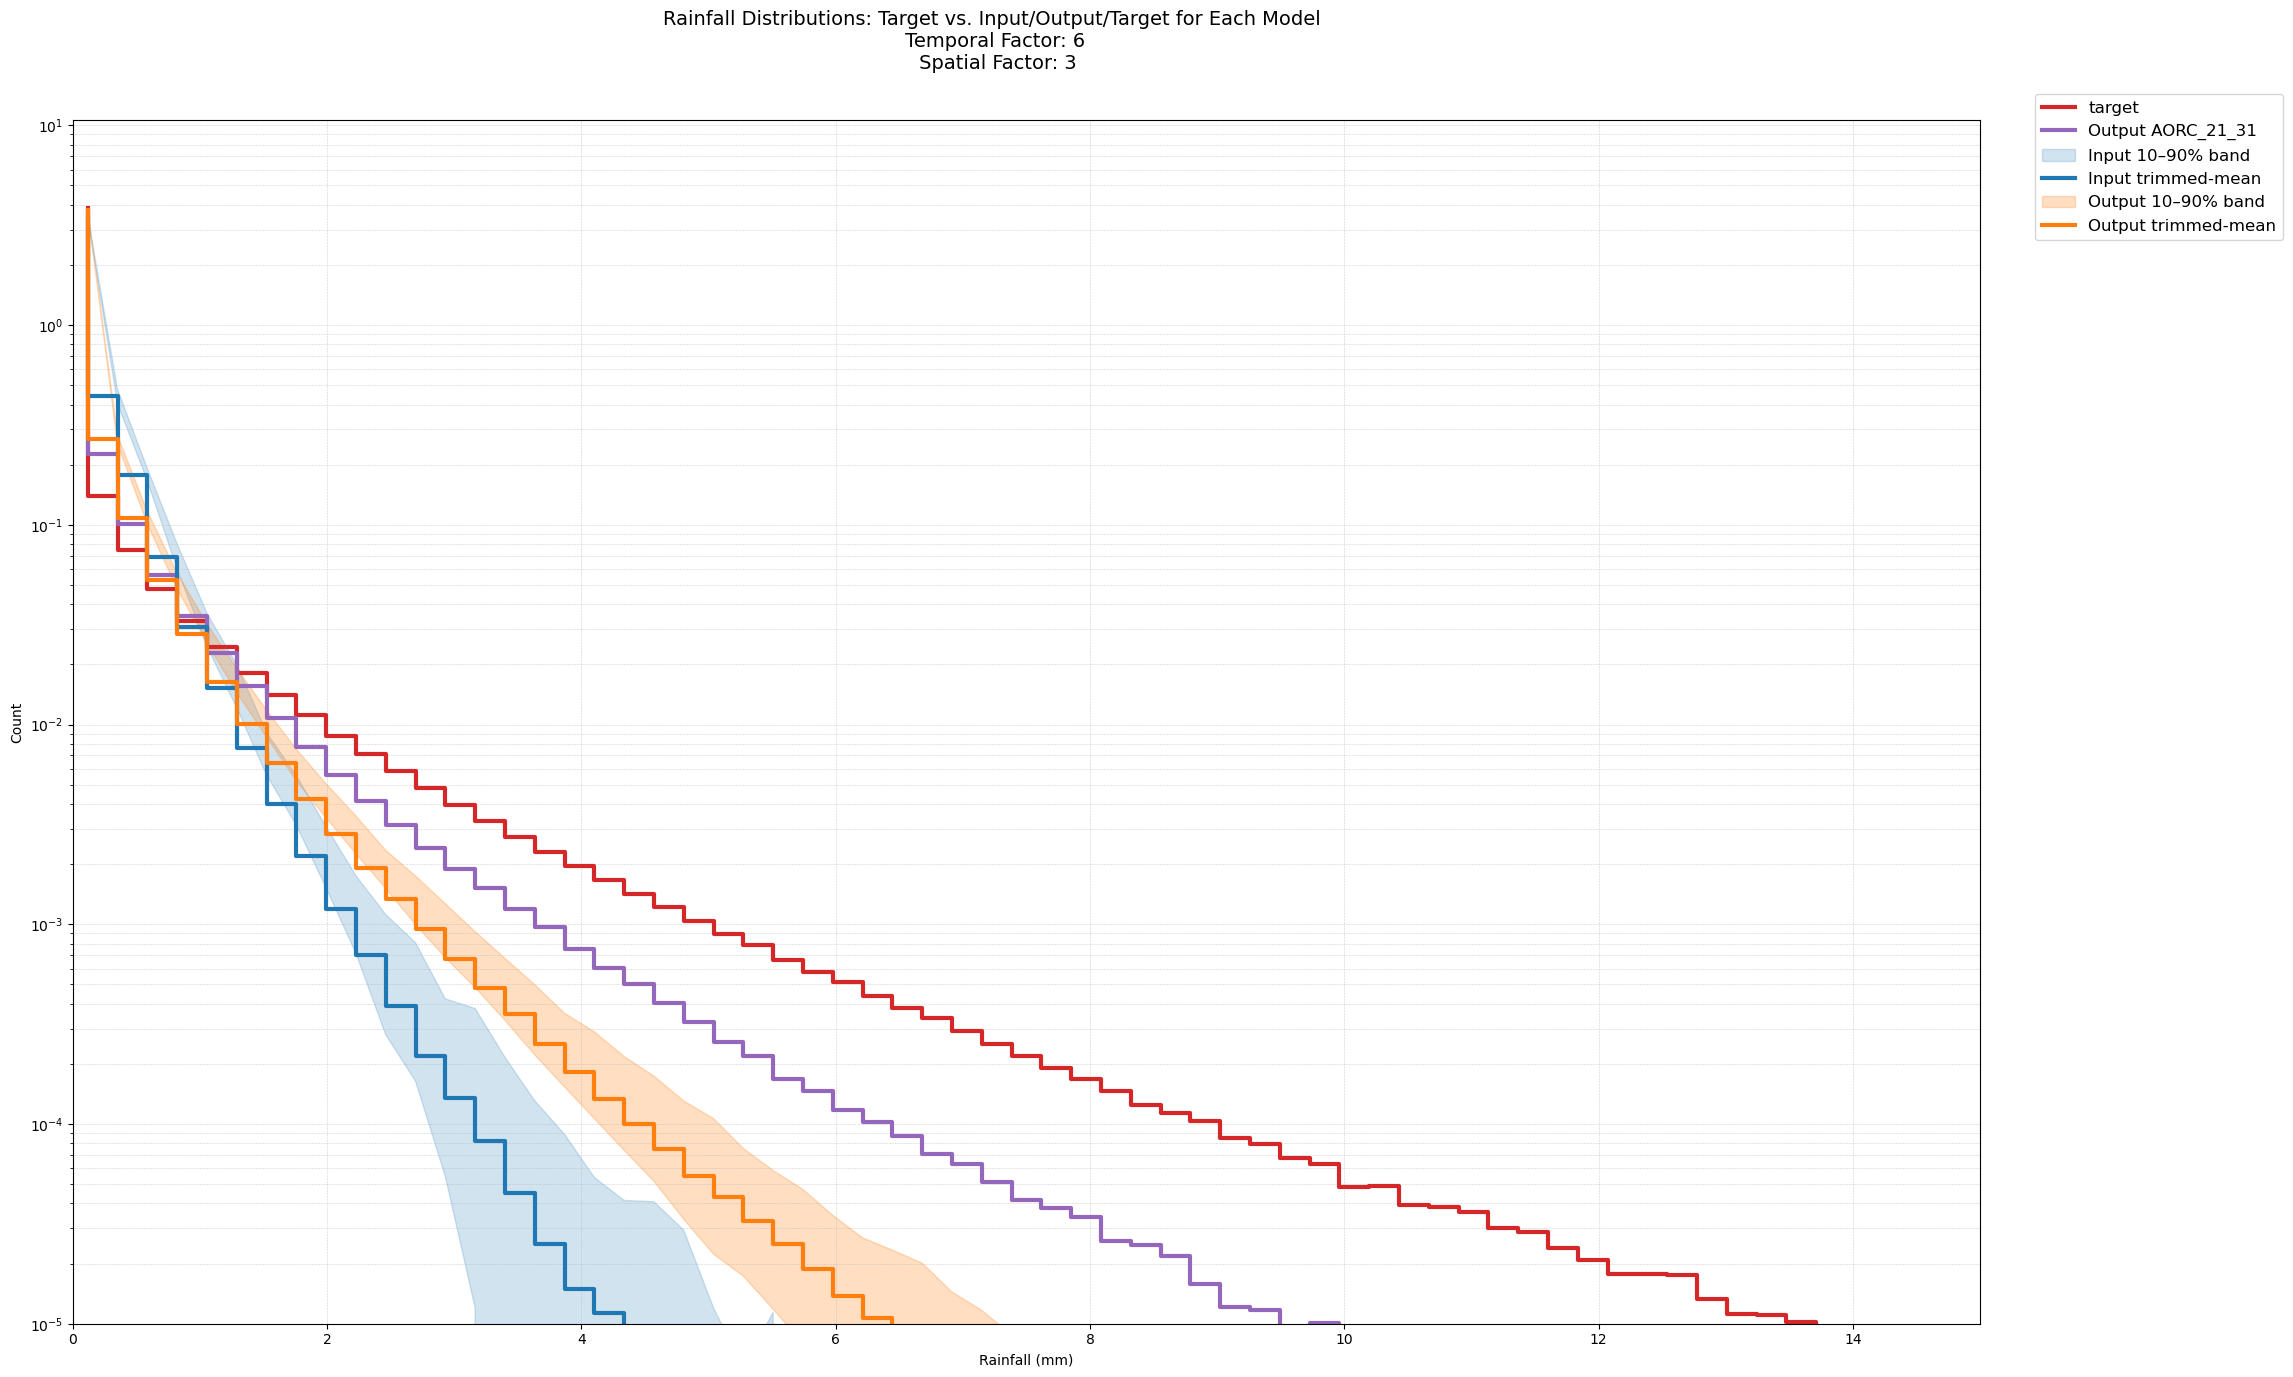

In [3]:
validation_dir = r"/scratch/jl14811/validation/6_3_3"
#validation_dir_baselines = r"/scratch/jl14811/validation/Baselines/"


# Define once
ensemble_models = sorted([
    "ACCESS-CM2", "ACCESS-ESM1-5", "BCC-CSM2-MR", "CanESM5", "CESM2", "CMCC-CM2-SR5",
    "CNRM-ESM2-1", "EC-Earth3-Veg-LR", "FGOALS-g3", "GFDL-CM4_gr2", "GFDL-ESM4",
    "INM-CM5-0", "IPSL-CM6A-LR", "KIOST-ESM", "MIROC-ES2L", "MIROC6", "MPI-ESM1-2-HR",
    "MPI-ESM1-2-LR", "MRI-ESM2-0", "NESM3", "NorESM2-LM", "TaiESM1", "AORC_21_31"
])

'''
ensemble_models = sorted([
    "ACCESS-CM2", "ACCESS-ESM1-5", "BCC-CSM2-MR", "CanESM5", "CESM2"
])

baseline_models = sorted([
    "baseline1", "baseline2", "baseline3", "baseline4", "baseline5", "baseline6", "baseline7", "baseline8"
])
'''

var_name = "pr"  # Common variable

# === Load shared target data ===
target_files = sorted(glob.glob(os.path.join(validation_dir, ensemble_models[0], "target*")))
target_flat = np.concatenate([
    xr.open_dataset(f)[var_name].values.ravel()
    for f in target_files
])
target_flat = target_flat[np.isfinite(target_flat)]
print("Target Loaded")
all_max = np.nanmax(target_flat)
# === Load shared Baselines data ===
'''
baseline_series = {}  # {baseline_name: np.ndarray}
for model in baseline_models:
    model_baseline_dir = os.path.join(validation_dir_baselines, model)
    baseline_files = sorted(glob.glob(os.path.join(model_baseline_dir, "baseline*")))
    baseline_flat = np.concatenate([
        xr.open_dataset(f)[var_name].values.ravel()
        for f in baseline_files
    ])
    baseline_flat = baseline_flat[np.isfinite(baseline_flat)]
    baseline_series[model] = baseline_flat
    print(f"{model} Loaded")
'''


# === plot settings ===
fig, ax = plt.subplots(figsize=(20, 14), constrained_layout=True)
#axes = axes.flatten()

all_input_flat = []
all_output_flat = []
all_target_flat = []

# --- Loop over models ---

for i, model in enumerate(ensemble_models):
    print(f"{model} starts to be loaded.")
    model_input_dir = os.path.join(validation_dir, model)
    model_output_dir = os.path.join(validation_dir, model)


    input_files = sorted(glob.glob(os.path.join(model_input_dir, "input*")))
    output_files = sorted(glob.glob(os.path.join(model_output_dir, "output*")))

    if not input_files or not output_files: #or not output_ecdf_files:
        print(f"Skipping {model}: missing files")
        continue

    with xr.open_dataset(input_files[0]) as ids:
        input_var_name = list(ids.data_vars)[0]
    with xr.open_dataset(output_files[0]) as ods:
        output_var_name = list(ods.data_vars)[0]

    # Flatten input and output
    input_flat = np.concatenate([
        xr.open_dataset(f)[input_var_name].values.ravel()
        for f in input_files
    ])
    input_flat = input_flat[np.isfinite(input_flat)]
    

    output_flat = np.concatenate([
        xr.open_dataset(f)[output_var_name].values.ravel()
        for f in output_files
    ])
    output_flat = output_flat[np.isfinite(output_flat)]
    # Histogram bins
    all_max = max(
        np.nanmax(input_flat), np.nanmax(output_flat), all_max 
        #max(np.nanmax(bflat) for bflat in baseline_series.values() if bflat.size > 0)
    )
    # add to the list
    all_input_flat.append(input_flat)
    all_output_flat.append(output_flat)
    if i % 4 == 0:
        ax.set_ylabel("Count")
    if i >= 20:
        ax.set_xlabel("Rainfall (mm)")


bins = np.linspace(0, all_max, 200)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
target_hist, _ = np.histogram(target_flat, bins=bins, density=True)
#ax.step(bin_centers, target_hist, where='mid', label=f'target', linewidth=2.0)
ax.step(
    bin_centers, target_hist, color='tab:red', linewidth=3, label='target'
)
input_hists = []
output_hists = []
for input_flat, output_flat, model in zip(all_input_flat, all_output_flat, ensemble_models):
    '''
    input_flat    = filter_top_half(input_flat,  thr=0.5, tie_method="average")
    output_flat   = filter_top_half(output_flat, thr=0.5, tie_method="average")
    target_flat   = filter_top_half(target_flat, thr=0.5, tie_method="average")
    baseline_flat = filter_top_half(baseline_flat, thr=0.5, tie_method="average")
    '''
    
    # Histograms
    input_hist, _ = np.histogram(input_flat, bins=bins, density=True)
    output_hist, _ = np.histogram(output_flat, bins=bins, density=True)
    
    if model == "AORC_21_31":
        '''
        ax.step(
            bin_centers, input_hist, color='tab:green', linewidth=3, label='Input AORC_21_31'
        )
        '''
        ax.step(
            bin_centers, output_hist, color='tab:purple', linewidth=3, label='Output AORC_21_31'
        )
        
        continue
    
    input_hists.append(input_hist)
    output_hists.append(output_hist)
    # Plot
    #ax.step(bin_centers, input_hist, where='mid', label=f'{model}_Input', linewidth=0.5)
    #ax.step(bin_centers, output_hist, where='mid', label=f'{model}_Output', linewidth=1.2)


# =====  10–90% =====
def band_and_trimmed_mean(hist_list, low_p=10, high_p=90):
    stack = np.vstack(hist_list)                      # [M, B]
    low = np.percentile(stack, low_p, axis=0)         # [B]
    high = np.percentile(stack, high_p, axis=0)       # [B]
    sorted_stack = np.sort(stack, axis=0)
    m = sorted_stack.shape[0]
    k_low = int(np.floor(low_p / 100.0 * m))
    k_high = int(np.ceil(high_p / 100.0 * m))
    trimmed_mean = sorted_stack[k_low:k_high, :].mean(axis=0)
    return low, high, trimmed_mean


# Input bands
in_low, in_high, in_mean = band_and_trimmed_mean(input_hists)
ax.fill_between(
    bin_centers, in_low, in_high,
    color='tab:blue', alpha=0.2, label='Input 10–90% band'
)
ax.step(
    bin_centers, in_mean, color='tab:blue', linewidth=3, label='Input trimmed-mean'
)

# Output bands
out_low, out_high, out_mean = band_and_trimmed_mean(output_hists)
ax.fill_between(
    bin_centers, out_low, out_high,
    color='tab:orange', alpha=0.25, label='Output 10–90% band'
)
ax.step(
    bin_centers, out_mean, color='tab:orange', linewidth=3, label='Output trimmed-mean'
)



# Baselines
'''
for bname, bflat in baseline_series.items():
    print(f"{bname} starts to be plot.")
    if bflat.size == 0:
        continue
    b_hist, _ = np.histogram(bflat, bins=bins, density=True)
    ax.step(bin_centers, b_hist, where='mid', linewidth=1.0, alpha=0.6, label=bname)
'''


    
ax.set_yscale('log')
fig.legend(loc='upper left', bbox_to_anchor=(1.02, 0.92), borderaxespad=0., fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.6)
ax.set_xlim(0, 15)
ax.set_ylim(1e-5)


# Hide unused axes
#ax.axis('off')
plt.suptitle("Rainfall Distributions: Target vs. Input/Output/Target for Each Model \n Temporal Factor: 6 \n Spatial Factor: 3", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Plot in a Different Plot

Target Loaded
ACCESS-CM2 starts to be loaded.
ACCESS-ESM1-5 starts to be loaded.
AORC_21_31 starts to be loaded.
BCC-CSM2-MR starts to be loaded.
CESM2 starts to be loaded.
CMCC-CM2-SR5 starts to be loaded.
CNRM-ESM2-1 starts to be loaded.
CanESM5 starts to be loaded.
EC-Earth3-Veg-LR starts to be loaded.
FGOALS-g3 starts to be loaded.
GFDL-CM4_gr2 starts to be loaded.
GFDL-ESM4 starts to be loaded.
INM-CM5-0 starts to be loaded.
IPSL-CM6A-LR starts to be loaded.
KIOST-ESM starts to be loaded.
MIROC-ES2L starts to be loaded.
MIROC6 starts to be loaded.
MPI-ESM1-2-HR starts to be loaded.
MPI-ESM1-2-LR starts to be loaded.
MRI-ESM2-0 starts to be loaded.
NESM3 starts to be loaded.
NorESM2-LM starts to be loaded.
TaiESM1 starts to be loaded.


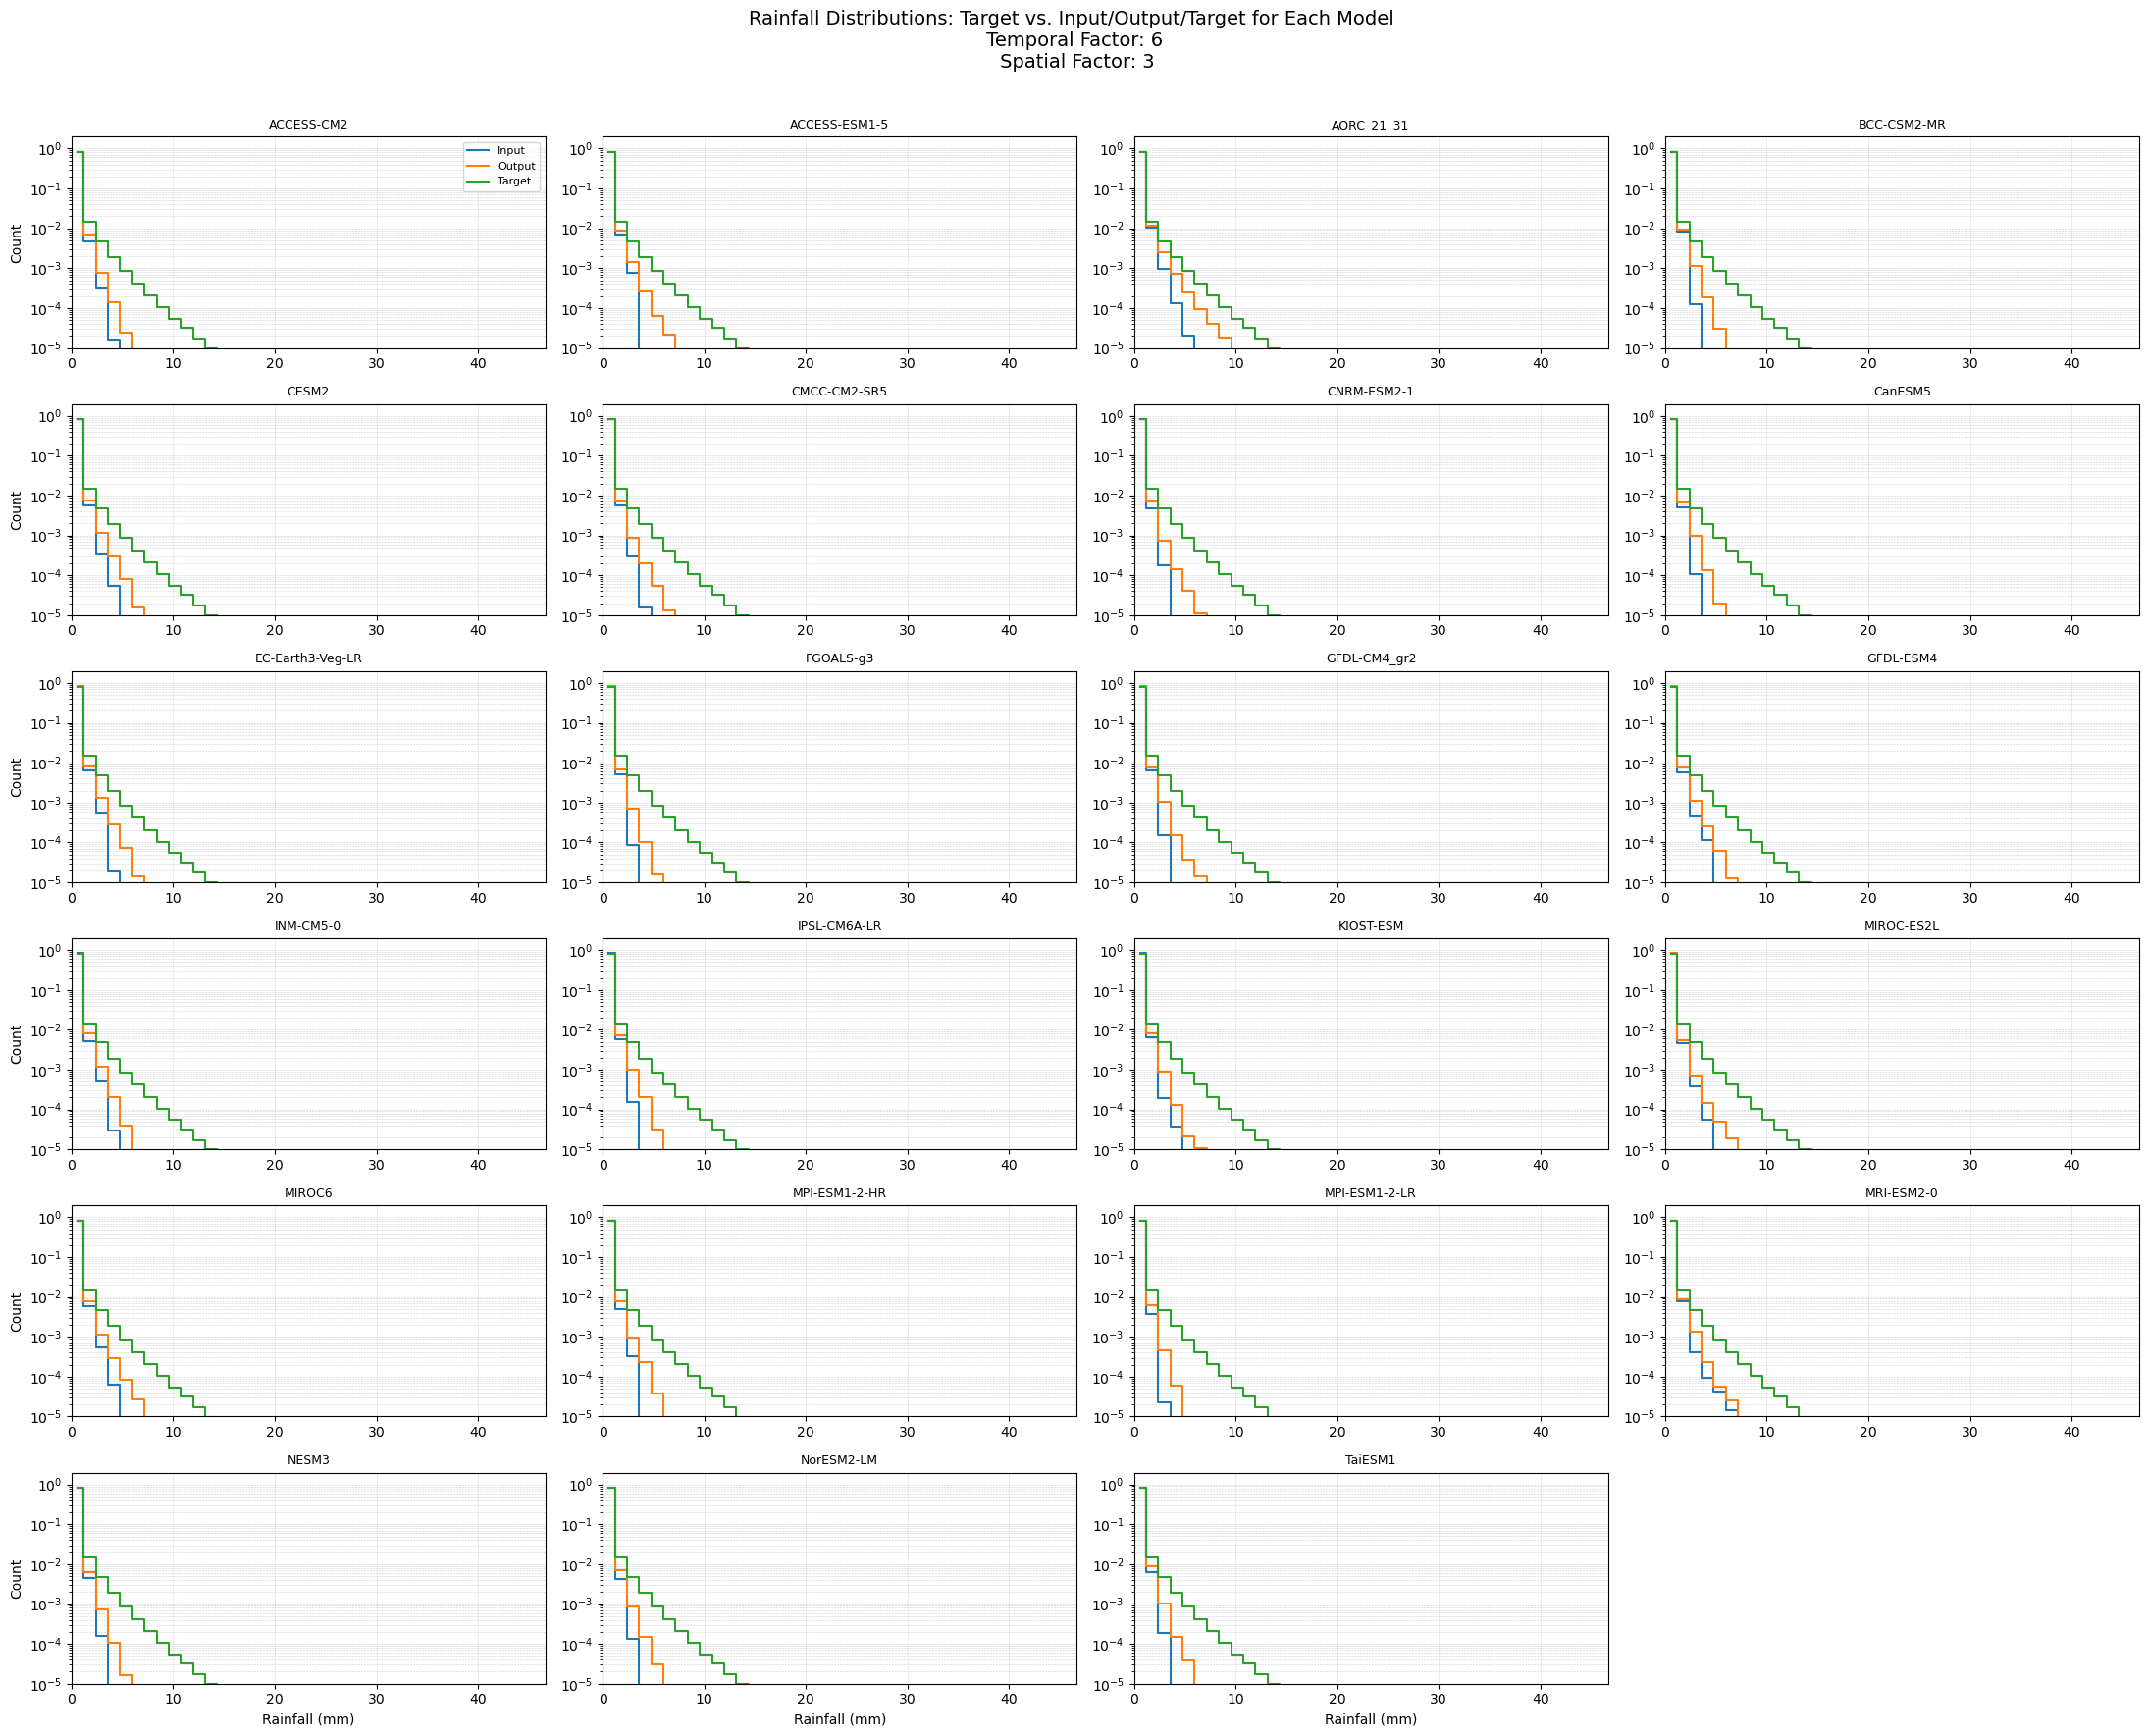

In [3]:
validation_dir = r"/scratch/jl14811/validation/6_3_3"
#validation_dir_baselines = r"/scratch/jl14811/validation/Baselines/"


# Define once
ensemble_models = sorted([
    "ACCESS-CM2", "ACCESS-ESM1-5", "BCC-CSM2-MR", "CanESM5", "CESM2", "CMCC-CM2-SR5",
    "CNRM-ESM2-1", "EC-Earth3-Veg-LR", "FGOALS-g3", "GFDL-CM4_gr2", "GFDL-ESM4",
    "INM-CM5-0", "IPSL-CM6A-LR", "KIOST-ESM", "MIROC-ES2L", "MIROC6", "MPI-ESM1-2-HR",
    "MPI-ESM1-2-LR", "MRI-ESM2-0", "NESM3", "NorESM2-LM", "TaiESM1", "AORC_21_31"
])

'''
ensemble_models = sorted([
    "AORC_21_31"
])

baseline_models = sorted([
    "baseline1", "baseline2", "baseline3", "baseline4", "baseline5", "baseline6", "baseline7", "baseline8"
])
'''

var_name = "pr"  # Common variable

# === Load shared target data ===
target_files = sorted(glob.glob(os.path.join(validation_dir, ensemble_models[0], "target*")))
target_flat = np.concatenate([
    xr.open_dataset(f)[var_name].values.ravel()
    for f in target_files
])
target_flat = target_flat[np.isfinite(target_flat)]
print("Target Loaded")

# === Load shared Baselines data ===
'''
baseline_series = {}  # {baseline_name: np.ndarray}
for model in baseline_models:
    model_baseline_dir = os.path.join(validation_dir_baselines, model)
    baseline_files = sorted(glob.glob(os.path.join(model_baseline_dir, "baseline*")))
    baseline_flat = np.concatenate([
        xr.open_dataset(f)[var_name].values.ravel()
        for f in baseline_files
    ])
    baseline_flat = baseline_flat[np.isfinite(baseline_flat)]
    baseline_series[model] = baseline_flat
    print(f"{model} Loaded")
'''


# === plot settings ===
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(22, 18))
axes = axes.flatten()


# --- Loop over models ---

for i, model in enumerate(ensemble_models):
    print(f"{model} starts to be loaded.")
    model_input_dir = os.path.join(validation_dir, model)
    model_output_dir = os.path.join(validation_dir, model)
    #model_output_ecdf_dir = os.path.join(validation_dir, f"{model}_ecdfloss_5")


    input_files = sorted(glob.glob(os.path.join(model_input_dir, "input*")))
    output_files = sorted(glob.glob(os.path.join(model_output_dir, "output*")))
    #output_ecdf_files = sorted(glob.glob(os.path.join(model_output_ecdf_dir, "output*")))

    if not input_files or not output_files: #or not output_ecdf_files:
        print(f"Skipping {model}: missing files")
        continue

    with xr.open_dataset(input_files[0]) as ids:
        input_var_name = list(ids.data_vars)[0]
    with xr.open_dataset(output_files[0]) as ods:
        output_var_name = list(ods.data_vars)[0]
    #with xr.open_dataset(output_ecdf_files[0]) as ods:
    #   output_ecdf_var_name = list(ods.data_vars)[0]

    # Flatten input and output
    input_flat = np.concatenate([
        xr.open_dataset(f)[input_var_name].values.ravel()
        for f in input_files
    ])
    input_flat = input_flat[np.isfinite(input_flat)]
    

    output_flat = np.concatenate([
        xr.open_dataset(f)[output_var_name].values.ravel()
        for f in output_files
    ])
    output_flat = output_flat[np.isfinite(output_flat)]

    '''
    output_ecdf_flat = np.concatenate([
        xr.open_dataset(f)[output_ecdf_var_name].values.ravel()
        for f in output_ecdf_files
    ])
    output_ecdf_flat = output_ecdf_flat[np.isfinite(output_ecdf_flat)]
    '''
    # Histogram bins
    all_max = max(
        np.nanmax(input_flat), np.nanmax(output_flat), np.nanmax(target_flat) 
        #max(np.nanmax(bflat) for bflat in baseline_series.values() if bflat.size > 0)
    )
    bins = np.linspace(0, all_max, 40)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])

    '''
    input_flat    = filter_top_half(input_flat,  thr=0.5, tie_method="average")
    output_flat   = filter_top_half(output_flat, thr=0.5, tie_method="average")
    target_flat   = filter_top_half(target_flat, thr=0.5, tie_method="average")
    baseline_flat = filter_top_half(baseline_flat, thr=0.5, tie_method="average")
    '''

    # Histograms
    input_hist, _ = np.histogram(input_flat, bins=bins, density=True)
    output_hist, _ = np.histogram(output_flat, bins=bins, density=True)
    #output_ecdf_hist, _ = np.histogram(output_ecdf_flat, bins=bins, density=True)
    target_hist, _ = np.histogram(target_flat, bins=bins, density=True)

    # Plot
    ax = axes[i]
    ax.step(bin_centers, input_hist, where='mid', label='Input', linewidth=1.5)
    ax.step(bin_centers, output_hist, where='mid', label='Output', linewidth=1.5)
    #ax.step(bin_centers, output_ecdf_hist, where='mid', label='Output_ecdf', linewidth=1.5)
    ax.step(bin_centers, target_hist, where='mid', label='Target', linewidth=1.5)


    # Baselines
    '''
    for bname, bflat in baseline_series.items():
        print(f"{bname} starts to be plot.")
        if bflat.size == 0:
            continue
        b_hist, _ = np.histogram(bflat, bins=bins, density=True)
        ax.step(bin_centers, b_hist, where='mid', linewidth=1.0, alpha=0.6, label=bname)
    '''


    
    ax.set_yscale('log')
    ax.set_title(model, fontsize=9)
    ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.6)
    ax.set_xlim(0, all_max)
    ax.set_ylim(1e-5)

    if i % 4 == 0:
        ax.set_ylabel("Count")
    if i >= 20:
        ax.set_xlabel("Rainfall (mm)")

# Shared legend
axes[0].legend(loc='upper right', fontsize=8)

# Hide unused axes
for ax in axes[len(ensemble_models):]:
    ax.axis('off')

plt.suptitle("Rainfall Distributions: Target vs. Input/Output/Target for Each Model \n Temporal Factor: 6 \n Spatial Factor: 3", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### One plot

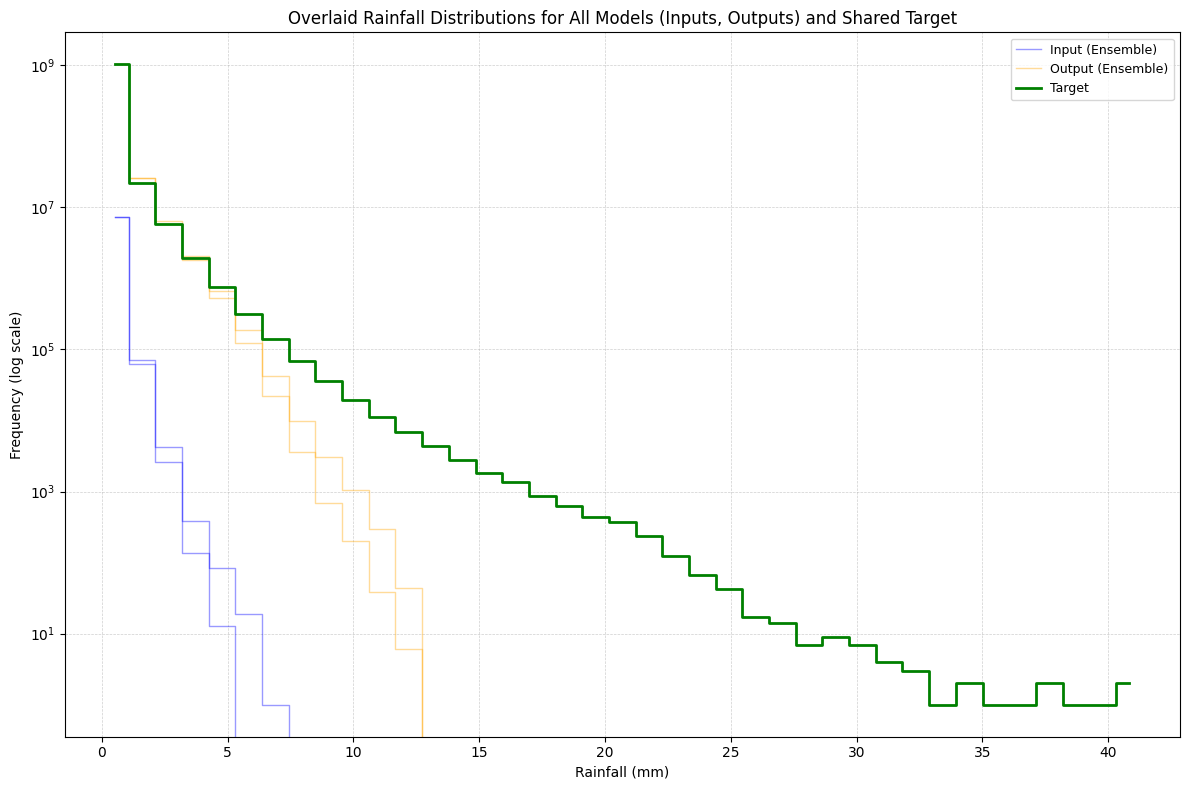

In [3]:
import os
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt



validation_dir = "C:\\Users\\bmk7346\\Documents\\Downscale_Proj\\Results\\2.AORC\\1981-2011\\validation_ecdfloss"


# === Setup ===

ensemble_models = sorted([
    "ACCESS-CM2","MIROC6"
])

var_name = "pr"  # Common variable

# === Load shared target data ===
target_files = sorted(glob.glob(os.path.join(validation_dir, ensemble_models[0], "target*")))
target_flat = np.concatenate([
    xr.open_dataset(f)[var_name].values.ravel()
    for f in target_files
])
target_flat = target_flat[np.isfinite(target_flat)]

# Determine histogram bins
max_target = np.nanmax(target_flat)
bins = np.linspace(0, max_target, 40)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# === Plot setup ===
plt.figure(figsize=(12, 8))
plotted_input_legend = False
plotted_output_legend = False

# === Plot each model’s input and output ===
for model in ensemble_models:
    model_dir = os.path.join(validation_dir, model)
    input_files = sorted(glob.glob(os.path.join(model_dir, "input*")))
    output_files = sorted(glob.glob(os.path.join(model_dir, "output*")))

    if not input_files or not output_files:
        print(f"Skipping {model}: missing files")
        continue

    with xr.open_dataset(input_files[0]) as ids:
        input_var = list(ids.data_vars)[0]
    with xr.open_dataset(output_files[0]) as ods:
        output_var = list(ods.data_vars)[0]

    input_data = np.concatenate([
        xr.open_dataset(f)[input_var].values.ravel()
        for f in input_files
    ])
    input_data = input_data[np.isfinite(input_data)]

    output_data = np.concatenate([
        xr.open_dataset(f)[output_var].values.ravel()
        for f in output_files
    ])
    output_data = output_data[np.isfinite(output_data)]

    # Update bins if needed
    local_max = max(np.nanmax(input_data), np.nanmax(output_data))
    if local_max > bins[-1]:
        bins = np.linspace(0, local_max, 40)
        bin_centers = 0.5 * (bins[1:] + bins[:-1])

    # Compute histograms
    input_hist, _ = np.histogram(input_data, bins=bins)
    output_hist, _ = np.histogram(output_data, bins=bins)

    # Plot with legend only once
    if not plotted_input_legend:
        plt.step(bin_centers, input_hist, where='mid', alpha=0.4, linewidth=1, color='blue', label='Input (Ensemble)')
        plotted_input_legend = True
    else:
        plt.step(bin_centers, input_hist, where='mid', alpha=0.4, linewidth=1, color='blue')

    if not plotted_output_legend:
        plt.step(bin_centers, output_hist, where='mid', alpha=0.4, linewidth=1, color='orange', label='Output (Ensemble)')
        plotted_output_legend = True
    else:
        plt.step(bin_centers, output_hist, where='mid', alpha=0.4, linewidth=1, color='orange')

# === Plot target once ===
target_hist, _ = np.histogram(target_flat, bins=bins)
plt.step(bin_centers, target_hist, where='mid', linewidth=2, color='green', label='Target')

# === Final styling ===
plt.yscale('log')
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency (log scale)")
plt.title("Overlaid Rainfall Distributions for All Models (Inputs, Outputs) and Shared Target")
plt.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.6)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()